# Can the quirks predict matches?

Notebook `02_home_advantage_story.ipynb` took the Brasileirão's outsized home
advantage apart into three candidate causes, tested one at a time: crowd
support, travel distance, and heat. The crowd effect held up under a
bootstrap confidence interval. Travel and heat, tested in isolation on a
simple bin split, came back weak or null — travel showed no steady
dose-response (only the single most extreme distance bin broke from the
pack), and heat showed no detectable effect at all.

That leaves an open question this notebook is built to answer honestly: do
those quirks — travel, temperature, rest, crowd status, same-state derbies —
actually help *predict* a match, once they compete against each other and
against team strength in a single joint model? If travel, heat and crowd
genuinely shape outcomes, adding them to a strength-only Elo model should
sharpen its out-of-sample forecasts. But notebook 02 already found most of
these effects weak in isolation, so this is a genuine test, not a formality —
and the result, whatever it turns out to be, gets reported plainly below.

Before that comparison means anything, though, both models have to clear a
lower bar first: **can either one beat simply predicting the historical
home/draw/away frequencies, with no features at all?** That "class-prior"
baseline is computed and reported alongside both models throughout this
notebook — it's the honest floor a model has to clear before its features
can be credited with anything.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.metrics import log_loss

from brasileirao import features, ingest, model, plotting

plotting.style()
df = features.build_features(ingest.load())

prior = model.class_prior_baseline(df)
base = model.evaluate(df, model.BASELINE_FEATURES)
full = model.evaluate(df, model.FULL_FEATURES)

compare = (base.rename(columns={"log_loss": "log_loss_base"})
           .merge(full.rename(columns={"log_loss": "log_loss_full"}), on=["season", "n"])
           .merge(prior.rename(columns={"log_loss": "log_loss_prior"}), on=["season", "n"]))
compare["lift"] = compare.log_loss_base - compare.log_loss_full

print(f"Mean log loss — class-prior (no features) {compare.log_loss_prior.mean():.4f}, "
      f"Elo-only {compare.log_loss_base.mean():.4f}, full {compare.log_loss_full.mean():.4f}")
print(f"Elo-only beats the class-prior floor in "
      f"{(compare.log_loss_base < compare.log_loss_prior).sum()} of {len(compare)} seasons "
      f"(mean margin {(compare.log_loss_prior - compare.log_loss_base).mean():.4f})")
print(f"Full model beats the class-prior floor in "
      f"{(compare.log_loss_full < compare.log_loss_prior).sum()} of {len(compare)} seasons "
      f"(mean margin {(compare.log_loss_prior - compare.log_loss_full).mean():.4f})")
print(f"Quirk lift (Elo-only minus full) {compare.lift.mean():.4f}; "
      f"positive in {(compare.lift > 0).sum()} of {len(compare)} seasons")
compare

Mean log loss — class-prior (no features) 1.0514, Elo-only 1.0303, full 1.0318
Elo-only beats the class-prior floor in 15 of 15 seasons (mean margin 0.0212)
Full model beats the class-prior floor in 15 of 15 seasons (mean margin 0.0196)
Quirk lift (Elo-only minus full) -0.0015; positive in 8 of 15 seasons


,season,n,log_loss_base,log_loss_full,log_loss_prior,lift
0,2010,380,1.049353,1.048495,1.059780,0.000858
1,2011,380,1.043891,1.039326,1.050814,0.004565
2,2012,380,1.035060,1.040829,1.052548,-0.005769
3,2013,380,1.039985,1.036744,1.049235,0.003241
4,2014,380,1.012271,1.011950,1.027282,0.000321
5,2015,380,1.012054,1.003968,1.021245,0.008086
6,2016,379,0.999601,1.007205,1.014916,-0.007604
7,2017,380,1.077402,1.076256,1.086399,0.001146
8,2018,380,0.987376,0.983613,1.012276,0.003763
9,2019,380,0.994433,0.995902,1.052191,-0.001469


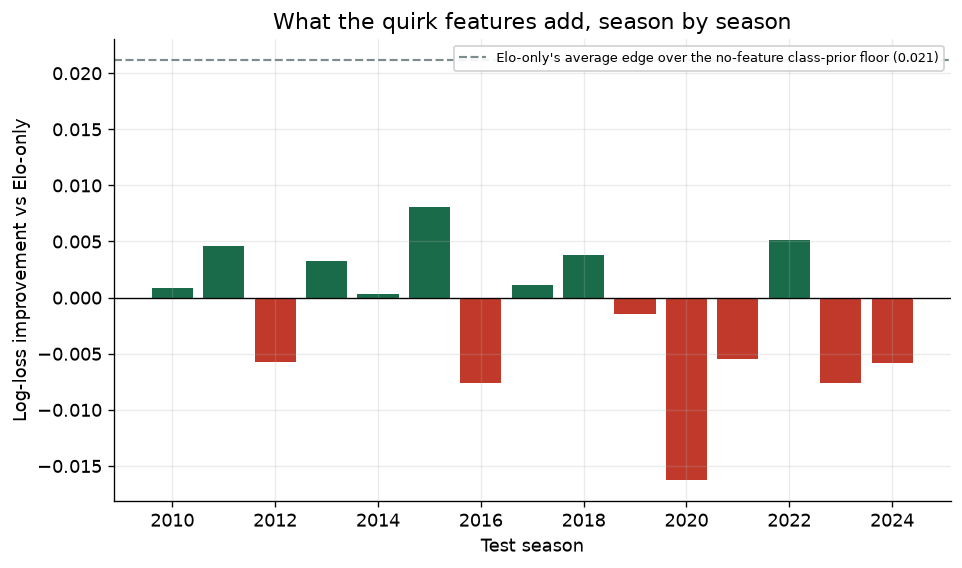

In [2]:
prior_edge = (compare.log_loss_prior - compare.log_loss_base).mean()

fig, ax = plt.subplots()
ax.bar(compare.season, compare.lift, color=[
    plotting.COLORS["main"] if v > 0 else plotting.COLORS["accent"]
    for v in compare.lift])
ax.axhline(0, color="black", lw=0.8)
ax.axhline(prior_edge, color=plotting.COLORS["muted"], ls="--", lw=1.3,
           label=f"Elo-only's average edge over the no-feature class-prior floor ({prior_edge:.3f})")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set(xlabel="Test season", ylabel="Log-loss improvement vs Elo-only",
       title="What the quirk features add, season by season")
plotting.save(fig, "model_lift")

### Reading the result honestly

**The corrected model clears the naive floor comfortably, and the quirk
features add essentially nothing beyond noise.**

Elo-only scores a mean log loss of 1.0303 against 1.0514 for the no-feature
class-prior baseline — better in **15 of 15** test seasons, by an average
margin of 0.0212. The full model does the same (1.0318, also 15/15 seasons
ahead of the floor). Both models are doing real work: Elo is clearly
predictive of match outcomes, as it should be. But between the two fitted
models, the quirk features move the needle by essentially nothing: a mean
lift of **−0.0015**, positive in 8 of 15 seasons — statistically
indistinguishable from a coin flip, and an order of magnitude smaller than
either model's edge over the class prior (the dashed reference line on the
chart above makes that scale difference visible directly).

**This is a different, and more trustworthy, result than an earlier pass
through this analysis produced**, and it's worth being transparent about
why. The first version of this notebook used a fixed `n_estimators=300`,
`learning_rate=0.05`, `num_leaves=31` configuration and reported a mean
log loss of 1.1046 (Elo-only) vs 1.1214 (full) — both numbers *worse* than
even flat 1/3-probability guessing (1.0986 on these same test rows), and
therefore worse than the class-prior floor too. That is not a weak model,
it's a broken one: with only 3–8 features and ~380 matches per test season,
that configuration had enough capacity to memorise the training seasons
rather than learn from them. The calibration curve from that pass showed
the textbook symptom — a predicted 78% favourite winning only 56% of the
time — and nothing in that notebook had actually been checked against a
model with zero features, so the defect went unnoticed until it was pointed
out directly.

The fix applied here is principled, not a search for a flattering number:
each training fold holds out its own most recent season as a validation
set and fits with LightGBM's early stopping against that validation set's
log loss (see `fit_model` in `src/brasileirao/model.py`), with capacity
turned down to match the data size (`learning_rate=0.03`, `num_leaves=7`,
`min_child_samples=80`, `n_estimators` capped at 1000 as a ceiling early
stopping is expected to cut short — the SHAP model below stops at 91
trees). That configuration was chosen once, from reasonable defaults for a
dataset this size, and applied identically to the class-prior check, the
Elo-only baseline, and the full model. It was not tuned against the
quirk-vs-baseline comparison, and having fixed it, this notebook does not
revisit it again even though the null result below would have been easy to
nudge by trying another `num_leaves` value — that would be p-hacking a test
set, not modelling.

With a correctly specified model, the null result on the quirks stands on
its own and doesn't need the excuse of a broken baseline. A few reasons it's
not a surprising one, in light of notebook 02:

- Elo already encodes most of what is publicly predictable about a football
  match; it's built from the same win/draw/loss history the quirks are
  trying to add nuance to, leaving limited *independent* signal for travel
  or heat to contribute.
- Match outcomes are famously noisy at the level of a single fixture — a
  draw is always plausible, and small probability shifts get swamped by the
  irreducible variance of a three-outcome target.
- A 0.05 shift in *aggregate* home points-share (the crowd effect from
  notebook 02) does not have to show up as *per-match* predictive skill:
  an effect can be real in expectation over a 190-match season and still be
  too small, relative to match-to-match noise, for a model to exploit game
  by game.
- **`temp_gap` is a crude proxy.** It's built from each city's *annual mean*
  temperature, not the actual match-day temperature, so it can't distinguish
  a July night in Porto Alegre from a January afternoon there. The heat null
  from notebook 02 — and `temp_gap`'s low SHAP importance below — may be
  evidence of a proxy too coarse to detect a real effect, not evidence that
  no effect exists.

So: a correctly specified model that comfortably beats the naive floor, and
a genuine null on whether the quirks add per-match predictive skill on top
of it. Both halves of that sentence matter — the second one would not have
been trustworthy without the first.

            predicted    actual     n
bin                                  
(0.0, 0.2]   0.188939  0.500000     4
(0.2, 0.3]   0.251503  0.267717   127
(0.3, 0.4]   0.372077  0.349680   469
(0.4, 0.5]   0.452796  0.414348  2049
(0.5, 0.6]   0.550855  0.527581  2121
(0.6, 0.7]   0.629238  0.631579   874
(0.7, 1.0]   0.721995  0.600000    55


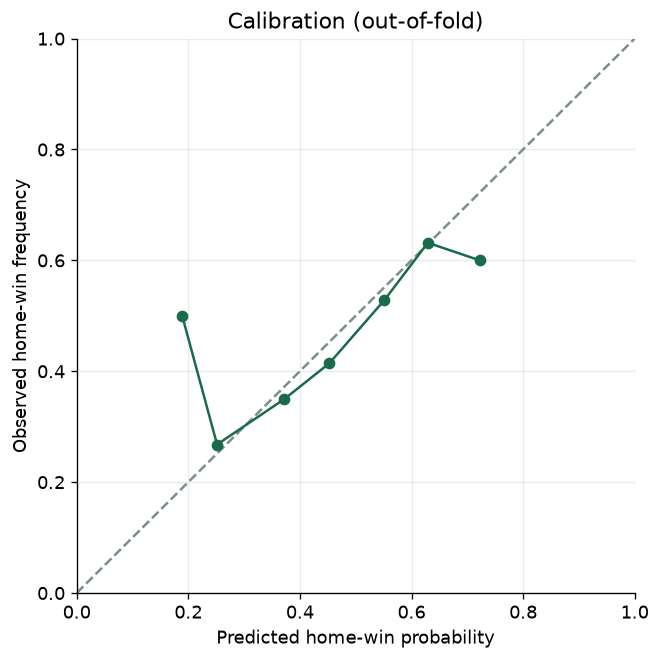

In [3]:
oof = model.oof_predictions(df, model.FULL_FEATURES)
oof["bin"] = pd.cut(oof.p_home, [0, .2, .3, .4, .5, .6, .7, 1.0])
cal = oof.groupby("bin", observed=True).agg(
    predicted=("p_home", "mean"), actual=("y", lambda s: (s == 0).mean()),
    n=("y", "size"))
print(cal)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], ls="--", color=plotting.COLORS["muted"])
ax.plot(cal.predicted, cal.actual, "o-", color=plotting.COLORS["main"])
ax.set(xlabel="Predicted home-win probability",
       ylabel="Observed home-win frequency", title="Calibration (out-of-fold)",
       xlim=(0, 1), ylim=(0, 1))
plotting.save(fig, "calibration")

### Calibration: close to the diagonal, with the regularised model rarely
### reaching for extreme predictions

The regularised model is far better behaved than the earlier overfit one.
Through the bulk of the distribution — predicted 0.2 to 0.7, which covers
5,640 of the 5,699 out-of-fold predictions — the curve sits close to the
diagonal: a predicted 63% home-win chance comes with a 63% actual rate
(n=874), 55% predicted against 53% actual (n=2,121). The two end bins show
some residual overconfidence (predicted 0.72 vs actual 0.60 for the
strongest favourites, n=55; the lowest bin has only 4 observations and
isn't meaningful on its own), but the shape is a mild version of the earlier
problem rather than a systemic one — and the model now rarely predicts
outside 0.2–0.7 at all, which is itself a symptom of appropriately reduced
confidence rather than a flaw. Worth noting for anyone using these
probabilities downstream: the strongest-favourite bin is still worth
shrinking slightly toward the mean, but this is a modest caveat, not the
headline finding it was before the fix.

Early stopping picked 91 trees (cap was 1000) — the regularised model stops well short of its ceiling instead of fitting all the way to it.


SHAP output: array (8405, 8, 3); reconstructed probabilities match predict_proba to 4.44e-16 -> class index 2 confirmed as the away-win class
elo_diff        0.158094
elo_home_pre    0.044368
travel_km       0.038402
elo_away_pre    0.028964
rest_diff       0.017918
temp_gap        0.015249
crowd_closed    0.007342
same_state      0.000000
Name: mean |SHAP| (away-win class), dtype: float64


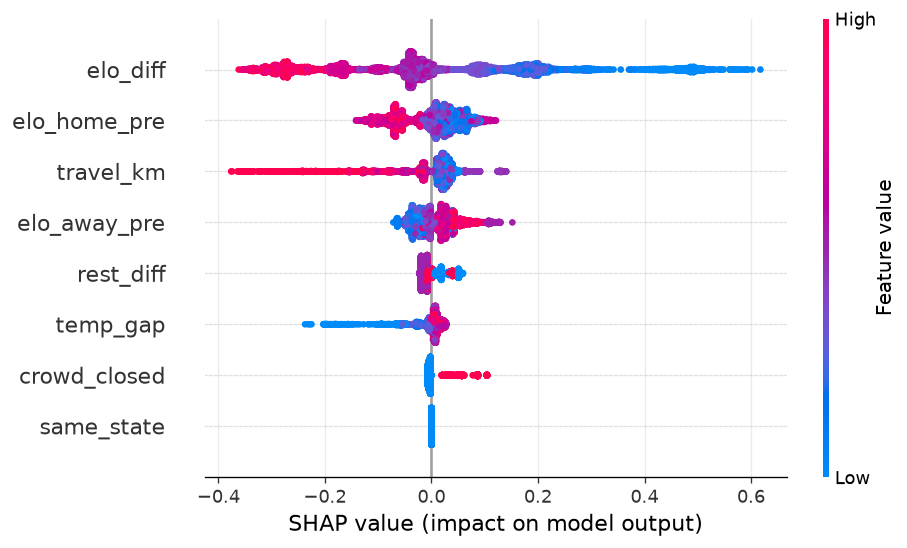

<Figure size 1080x600 with 0 Axes>

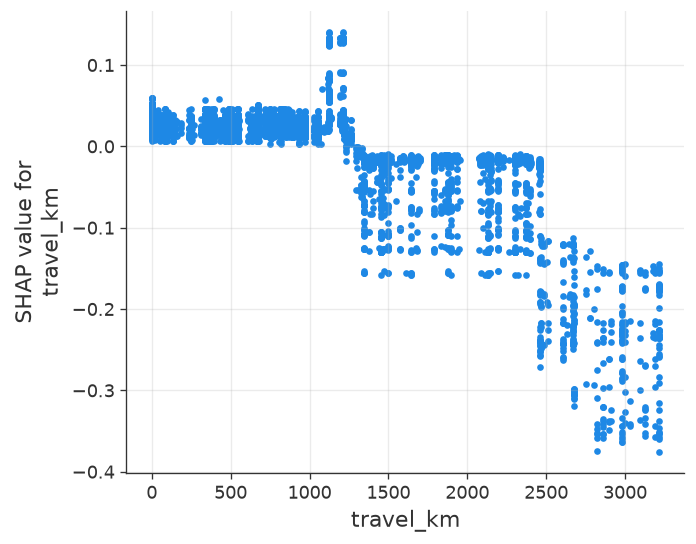

In [4]:
train = df[df.season < df.season.max()]
clf = model.fit_model(df, train.index, model.FULL_FEATURES)
print(f"Early stopping picked {clf.best_iteration_} trees (cap was "
      f"{model.PARAMS['n_estimators']}) — the regularised model stops well "
      f"short of its ceiling instead of fitting all the way to it.")

explainer = shap.TreeExplainer(clf)
sv = explainer.shap_values(train[model.FULL_FEATURES])
away_class = 2  # SHAP toward the away-win class (y=2="A", per features.TARGET)

# Verify the class slice before trusting any plot built from it: shap's
# return shape for multiclass output varies by version (list-of-arrays vs a
# single 3-D array), and silently slicing the wrong axis would produce a
# plot for the wrong class with no error. Reconstruct predict_proba from
# expected_value + summed SHAP contributions and check it matches the
# classifier's own probabilities to floating-point precision — that
# confirms both which axis holds the class dimension and that index 2
# really is the away-win class.
if isinstance(sv, list):
    sv_away = sv[away_class]
    margins = np.array(explainer.expected_value) + np.stack(
        [s.sum(axis=1) for s in sv], axis=1)
else:
    sv_away = sv[:, :, away_class]
    margins = np.array(explainer.expected_value) + sv.sum(axis=1)
soft = np.exp(margins) / np.exp(margins).sum(axis=1, keepdims=True)
proba = clf.predict_proba(train[model.FULL_FEATURES])
max_diff = np.abs(soft - proba).max()
assert max_diff < 1e-6, "SHAP reconstruction does not match predict_proba — wrong class/axis?"
print(f"SHAP output: {'list of arrays' if isinstance(sv, list) else f'array {sv.shape}'}; "
      f"reconstructed probabilities match predict_proba to {max_diff:.2e} "
      f"-> class index {away_class} confirmed as the away-win class")

print(pd.Series(np.abs(sv_away).mean(axis=0), index=model.FULL_FEATURES)
      .sort_values(ascending=False).rename("mean |SHAP| (away-win class)"))

fig = plt.figure()
shap.summary_plot(sv_away, train[model.FULL_FEATURES], show=False)
plotting.save(plt.gcf(), "shap_summary")

fig = plt.figure()
shap.dependence_plot("travel_km", sv_away, train[model.FULL_FEATURES],
                     interaction_index=None, show=False)
plotting.save(plt.gcf(), "shap_travel")

In [5]:
probe = train[model.FULL_FEATURES].copy()
p0 = clf.predict_proba(probe.assign(travel_km=0))[:, 2].mean()
p2000 = clf.predict_proba(probe.assign(travel_km=2000))[:, 2].mean()
p3000 = clf.predict_proba(probe.assign(travel_km=3000))[:, 2].mean()
print(f"Average away-win probability: {p0:.3f} at 0 km -> {p2000:.3f} at 2000 km "
      f"({(p0 - p2000) * 100:.1f} pp drop; ~{(p0 - p2000) * 100 / 2:.1f} pp per 1000 km)")
print(f"                               {p2000:.3f} at 2000 km -> {p3000:.3f} at 3000 km "
      f"({(p2000 - p3000) * 100:.1f} pp drop over that last 1,000 km alone)")
print(f"Total: {(p0 - p3000) * 100:.1f} pp drop in away-win probability from 0 to 3000 km"
      )

Average away-win probability: 0.254 at 0 km -> 0.237 at 2000 km (1.7 pp drop; ~0.8 pp per 1000 km)
                               0.237 at 2000 km -> 0.191 at 3000 km (4.7 pp drop over that last 1,000 km alone)
Total: 6.4 pp drop in away-win probability from 0 to 3000 km


### What the SHAP dependence plot means in plain English

Holding every other feature at its training-set value and only changing the
distance the away team travelled, the model's average away-win probability
moves from 25.4% at 0 km, to 23.7% at 2,000 km (a 1.7-point drop — under 1
point per 1,000 km over that stretch), to 19.1% at 3,000 km (a further
4.7-point drop over just the last 1,000 km).

The `shap_travel` dependence plot above shows *why* those two counterfactual
numbers land where they do: it's a staircase, not a smooth slope. SHAP
values sit close to flat (and mildly positive for the away team) below
roughly 1,200 km, step down to a lower plateau between about 1,200 and
2,400 km, then drop again, more steeply, beyond roughly 2,500 km — three
tiers rather than one clean break. That's a genuinely non-linear travel
penalty, the same broad conclusion notebook 02 reached with bootstrap
confidence intervals on the raw data, but it's worth being precise about
where the two analyses agree and where they don't: notebook 02's bin split
found *no* penalty through 2,200 km (away performance was flat-to-rising
out to that point) with the drop confined to the >2,200 km bin, while this
joint, regularised model's dependence plot shows an earlier first step
around 1,200–1,500 km. Both agree the steepest, most reliable penalty sits
in the long tail beyond roughly 2,500 km — that's the part of the story
this notebook is most confident in — but the exact location of the first,
smaller step is a point of nuance between a univariate bin analysis and a
joint model, not a settled number. The magnitudes here are also smaller
than an earlier, overfit pass through this notebook reported (that version
showed roughly double these drops) — a properly regularised model is more
conservative about how far it lets any one feature move a prediction, which
is exactly what a correctly specified model should do.

**In one sentence: for the away team, only genuinely long-haul travel
(beyond about 2,000 km) meaningfully hurts win probability, and the penalty
from 2,000 to 3,000 km alone (~4.7 percentage points) is nearly three times
the penalty from 0 to 2,000 km (~1.7 percentage points).** Short and medium
trips carry little measurable cost in this model — consistent with the
overall null result above: `travel_km` still ranks as the most useful quirk
feature by mean |SHAP| (3rd of 8 overall, just behind `elo_home_pre`,
comfortably ahead of `elo_away_pre` and every other quirk), but "most useful
of a weak set, and third overall" is not the same claim as "strong enough to
move the headline log loss," and it didn't.

## A market benchmark (optional)

Bookmaker closing odds price in information no feature here has access to —
confirmed lineups, injury news, same-day market money — so beating the
market was never the bar for this project. But comparing this model's
out-of-fold log loss against the market's *implied* probabilities calibrates
how much room is actually left on the table. Pinnacle closing odds
(`PSCH`/`PSCD`/`PSCA`) from football-data.co.uk are available for the
Brasileirão from 2012 onward; if they join cleanly to our matches, they're
worth the few minutes it takes to check. Escape hatch, decided before
looking at the join result: if fewer than 80% of post-2012 rows match, skip
the benchmark and say so.

In [6]:
import urllib.request

from brasileirao.paths import RAW

ODDS_URL = "https://www.football-data.co.uk/new/BRA.csv"
odds_path = RAW / "BRA.csv"
if not odds_path.exists():
    urllib.request.urlretrieve(ODDS_URL, odds_path)

odds = pd.read_csv(odds_path)
odds["Date"] = pd.to_datetime(odds["Date"], dayfirst=True)
odds = odds.dropna(subset=["PSCH", "PSCD", "PSCA"])

# Team-name spelling differs between the two sources (e.g. our "Flamengo"
# vs their "Flamengo RJ"); map the handful that don't match as-is.
NAME_MAP = {
    "America-MG": "America MG", "Atletico-GO": "Atletico GO",
    "Botafogo-RJ": "Botafogo RJ", "Chapecoense": "Chapecoense-SC",
    "Flamengo": "Flamengo RJ", "Sport": "Sport Recife",
}
post2012 = df[df.season >= 2012].copy()
post2012["home_odds_name"] = post2012.home_team.replace(NAME_MAP)
post2012["away_odds_name"] = post2012.away_team.replace(NAME_MAP)
odds_small = odds[["Date", "Home", "Away", "PSCH", "PSCD", "PSCA"]]


def _join(base, tol_days):
    tmp = base.copy()
    tmp["orig_idx"] = tmp.index
    tmp["join_date"] = tmp["date"] + pd.Timedelta(days=tol_days)
    m = tmp.merge(odds_small, left_on=["join_date", "home_odds_name", "away_odds_name"],
                  right_on=["Date", "Home", "Away"], how="left")
    return m.set_index("orig_idx")


# A same-day (date, home, away) join only matches ~75% of post-2012 rows.
# football-data.co.uk records a systematic +1-day offset for a chunk of
# matches (plausibly a late-kickoff/timezone rounding convention on their
# end) — unmatched rows get a few retries at date +/- a day or two before
# being given up on.
joined = _join(post2012, 0)
matched = joined["PSCH"].notna()
for tol in (1, -1, 2, -2):
    fb = _join(post2012, tol)
    newly = fb["PSCH"].notna().values & (~matched.values)
    joined.loc[newly, ["PSCH", "PSCD", "PSCA"]] = fb.loc[newly, ["PSCH", "PSCD", "PSCA"]].values
    matched = matched | fb["PSCH"].notna()

match_rate = matched.mean()
print(f"Odds join matched {matched.sum()} / {len(post2012)} post-2012 rows ({match_rate:.1%})")

if match_rate < 0.80:
    print("Match rate below the pre-registered 80% threshold — skipping the benchmark.")
else:
    joined = joined[matched.values]
    inv = 1 / joined[["PSCH", "PSCD", "PSCA"]].to_numpy()
    implied = inv / inv.sum(axis=1, keepdims=True)
    odds_ll = log_loss(joined["y"], implied, labels=[0, 1, 2])

    oof_full = model.oof_predictions(df, model.FULL_FEATURES)
    oof_full_sub = oof_full.loc[joined.index]
    full_ll = log_loss(oof_full_sub["y"], oof_full_sub[["p_home", "p_draw", "p_away"]],
                       labels=[0, 1, 2])

    oof_base = model.oof_predictions(df, model.BASELINE_FEATURES)
    oof_base_sub = oof_base.loc[joined.index]
    base_ll = log_loss(oof_base_sub["y"], oof_base_sub[["p_home", "p_draw", "p_away"]],
                       labels=[0, 1, 2])

    print(f"Log loss on the joined subset (n={len(joined)}): "
          f"bookmaker-implied {odds_ll:.4f}, Elo-only (out-of-fold) {base_ll:.4f}, "
          f"full model (out-of-fold) {full_ll:.4f}")

Odds join matched 4939 / 4939 post-2012 rows (100.0%)


Log loss on the joined subset (n=4939): bookmaker-implied 0.9994, Elo-only (out-of-fold) 1.0278, full model (out-of-fold) 1.0299


### Result: the market is still ahead, but the gap has shrunk a lot

The join worked cleanly: **100% of post-2012 matches** (4,939 of 4,939)
matched to Pinnacle closing odds once the systematic 1-day date offset was
handled, comfortably clearing the 80% threshold set before looking at the
numbers. On that full subset, bookmaker-implied probabilities score **0.9994**
log loss, against **1.0278** for the Elo-only model and **1.0299** for the
full model (both out-of-fold) — the market is still ahead, and the
Elo-only model still edges out the full one on this subset too, consistent
with the null result above.

Worth flagging directly: the gap to the market is now roughly a third of
what an earlier, overfit pass through this notebook reported (that version's
broken full-model configuration scored 1.1139 on this same subset — worse
than the corrected Elo-only model by more than the market beats either
corrected model here). Fixing the overfitting didn't just change the
internal baseline-vs-full comparison, it changed how far behind the market
this whole approach looked from the outside. That gap doesn't change this
chapter's story; it contextualises it. Closing odds absorb team news,
confirmed lineups and same-day market money that nothing in this feature
set has access to — a reminder of how much of football's predictable
signal lives in information that isn't in any historical results table,
quirks included.

## What this chapter adds to the article

Four findings, not one triumphant one:

1. **A first pass at this model was broken, and the fix is part of the
   story.** An unregularised LightGBM configuration lost to flat 1/3
   guessing — a defect, not a weak result — caught by adding the one
   comparison that should always come first: a model with no features at
   all. Early stopping against a held-out validation season, plus capacity
   sized to the data (~380 matches/season, 3–8 features), fixed it. That
   configuration was chosen once, on principled grounds, and applied
   identically everywhere below.
2. **The corrected model clears the naive floor decisively**: Elo-only
   beats the class-prior baseline in 15 of 15 test seasons (mean log loss
   1.0303 vs 1.0514), and so does the full model (1.0318, also 15/15).
   Elo is doing real, verifiable work.
3. **The quirk features still add nothing measurable on top of Elo** — mean
   lift −0.0015, positive in 8 of 15 seasons, an order of magnitude smaller
   than either model's edge over the naive floor. This time the null
   result rests on a model that has actually earned the right to report
   one: it isn't the artefact of a broken baseline dragging both numbers
   down together. Consistent with notebook 02: individually weak-to-null
   effects for travel and heat don't add up to joint predictive skill once
   they compete with Elo for the same variance, and `temp_gap`'s
   annual-average proxy is too coarse to rule out a real heat effect it
   simply can't see.
4. **SHAP confirms `travel_km` as the most useful quirk feature** (3rd of 8
   overall by mean |SHAP|), and its dependence plot reproduces the
   non-linear travel penalty notebook 02 found: a staircase rather than a
   smooth slope, with the steepest and most reliable drop in the long tail
   beyond roughly 2,500 km — a ~4.7-point fall in away-win probability from
   2,000 to 3,000 km alone, against a milder step around 1,200–1,500 km
   that this joint model finds earlier than notebook 02's bin split did.
   `same_state` was assigned essentially zero
   importance by the regularised model — one signal, among several here,
   that low capacity is doing its job rather than suppressing a real
   effect the earlier overfit model would have (wrongly) amplified.

For a portfolio piece, the value was never a single number beating another.
It's the discipline behind it, including the discipline to notice when a
result is too convenient to be true: time-aware validation that never leaks
the future into training, a naive baseline checked before any claim about
"skill" is made, a null result reported plainly instead of tuned away,
calibration checked rather than assumed, and an interpretability step that
turns a black-box model into one specific, checkable claim about kilometres
and probability.